<a href="https://colab.research.google.com/github/sahilabdushomat/UTS_PCD/blob/main/UTS_PCD_23424041.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan pilih gambar (.jpg atau .png) yang ingin diolah:


Saving Cuplikan layar 2025-01-05 101114.png to Cuplikan layar 2025-01-05 101114.png


/tmp/ipykernel_430/1311628056.py:21: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_430/1311628056.py:21: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))


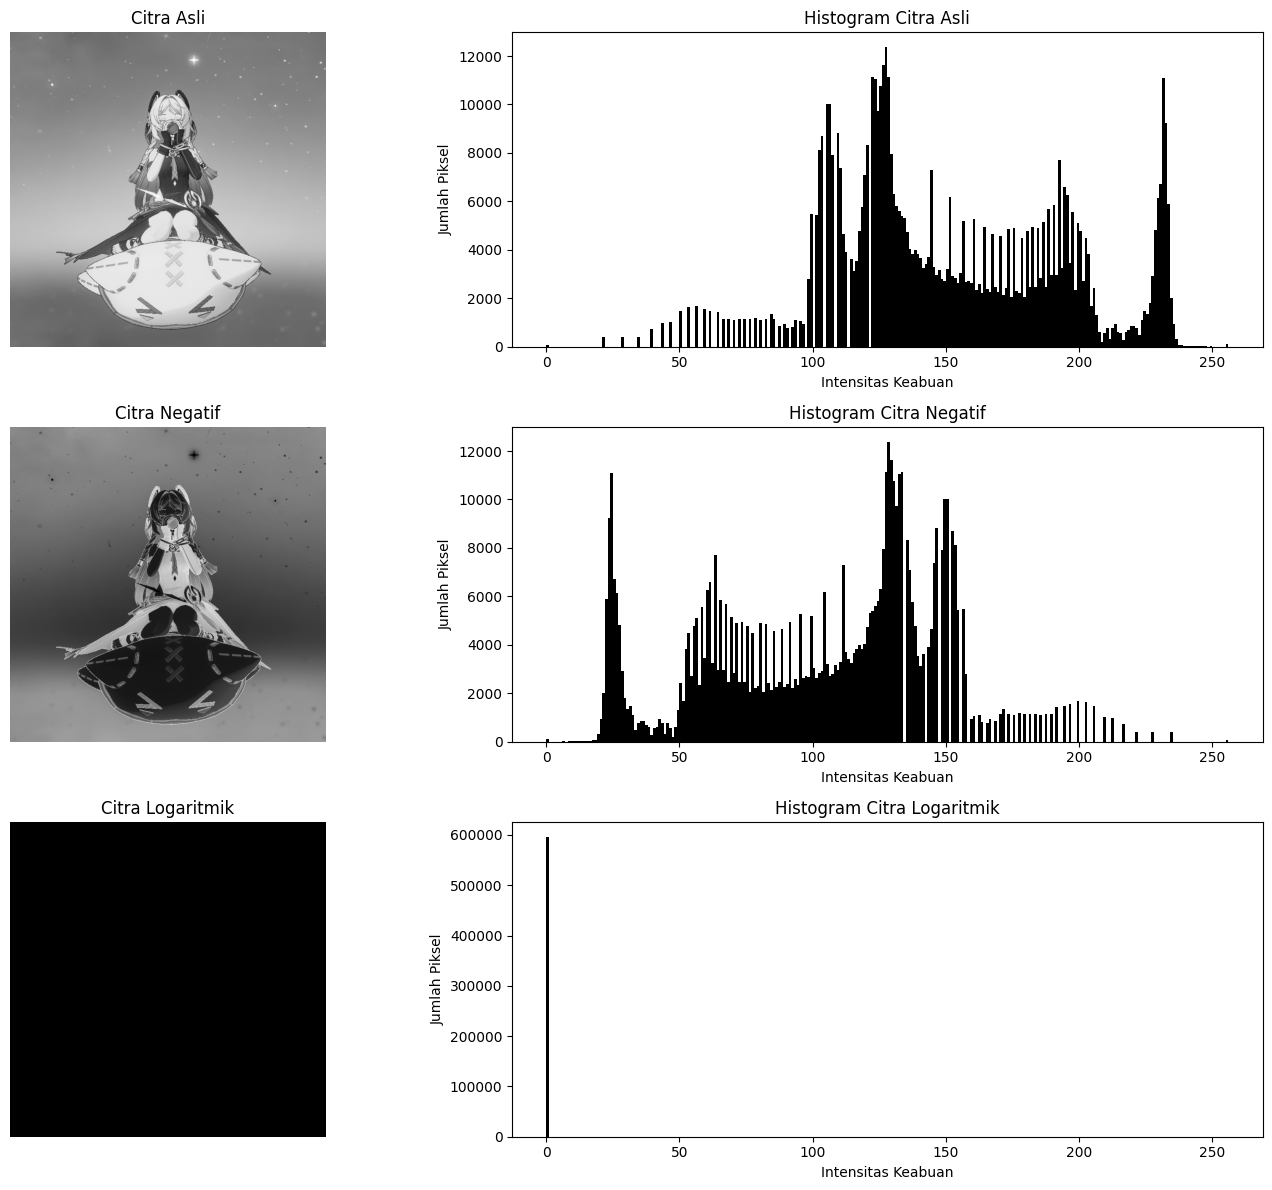

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Langkah 1: Unggah Gambar ---
print("Silakan pilih gambar (.jpg atau .png) yang ingin diolah:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# --- Langkah 2: Baca citra sebagai Grayscale ---
img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# --- Langkah 3: Transformasi Negatif ---
# Rumus: G = 255 - F
img_negative = 255 - img

# --- Langkah 4: Transformasi Logaritmik ---
# Rumus: G = c * log(1 + F)
# c = 255 / log(1 + max(F))
c = 255 / np.log(1 + np.max(img))
img_log = c * (np.log(img + 1.0))
img_log = np.array(img_log, dtype=np.uint8)

# --- Langkah 5: Tampilkan Gambar dan Histogram ---
titles = ['Citra Asli', 'Citra Negatif', 'Citra Logaritmik']
images = [img, img_negative, img_log]

plt.figure(figsize=(15, 12))

for i in range(3):
    # Tampilkan Citra
    plt.subplot(3, 2, 2*i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

    # Tampilkan Histogram
    plt.subplot(3, 2, 2*i + 2)
    plt.hist(images[i].ravel(), bins=256, range=[0, 256], color='black')
    plt.title(f'Histogram {titles[i]}')
    plt.xlabel('Intensitas Keabuan')
    plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()